# 已有回測結果：日期過濾與重新製圖

## Goal

直接讀取已算好的 `summary_all_daily_pairs.csv`，依自訂日期區間與排除日期重新製圖。這個 notebook **不會重跑 hftbacktest**。

## Setup

主要邏輯位於 `future_spot/arbitrage/result_replot.py`；這裡只保留路徑與日期設定。

In [6]:
from pathlib import Path
import sys
import importlib
import pandas as pd
from IPython.display import Image, display

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / 'future_spot').exists():
    WORKSPACE_ROOT = CURRENT_DIR
elif CURRENT_DIR.name == 'notebooks' and CURRENT_DIR.parent.name == 'future_spot':
    WORKSPACE_ROOT = CURRENT_DIR.parents[1]
else:
    raise FileNotFoundError('請從 repository root 或 future_spot/notebooks 執行此 notebook')
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))

import future_spot.arbitrage.result_replot as result_replot
importlib.reload(result_replot)
from future_spot.arbitrage.result_replot import (
    PlotInterval,
    interval_diagnostics,
    load_precomputed_summary,
    save_interval_figures,
)

### 1. 調整資料來源、日期區間與排除日

- `OUTPUT_DIRS`：已完成回測的輸出資料夾，可放一個或多個。
- `PLOT_INTERVALS`：每段各自設定名稱、起訖日與排除日期。
- 下列四天是目前日損益排序找到的鉅額虧損候選日，可自行增刪。

In [7]:
OUTPUT_DIRS = [
    WORKSPACE_ROOT / 'future_spot/output/hbt_daily_full_market_20260101_20260131_latency_10ms',
    WORKSPACE_ROOT / 'future_spot/output/hbt_daily_full_market_20260201_20260228_latency_10ms',
    WORKSPACE_ROOT / 'future_spot/output/hbt_daily_full_market_20260301_20260331_latency_10ms',
    WORKSPACE_ROOT / 'future_spot/output/hbt_daily_full_market_20260401_20260430_latency_10ms',
    WORKSPACE_ROOT / 'future_spot/output/hbt_daily_full_market_20260501_20260531_latency_10ms',
    # 此既有資料夾的 summary 實際涵蓋 2026-06-01 至 2026-06-30。
    WORKSPACE_ROOT / 'future_spot/output/hbt_daily_full_market_20260521_20260526_latency_10ms',
    WORKSPACE_ROOT / 'future_spot/output/hbt_daily_full_market_20260701_20260731_latency_10ms',
]

PLOT_INTERVALS = [
    PlotInterval('2026-01', '2026-01-01', '2026-01-31'),
    PlotInterval('2026-02', '2026-02-01', '2026-02-28'),
    PlotInterval('2026-03', '2026-03-01', '2026-03-31'),
    PlotInterval('2026-04', '2026-04-01', '2026-04-30', ('2026-04-23',)),
    PlotInterval('2026-05', '2026-05-01', '2026-05-31', ('2026-05-04', '2026-05-19')),
    PlotInterval('2026-06', '2026-06-01', '2026-06-30', ('2026-06-24',)),
    PlotInterval('2026-07', '2026-07-01', '2026-07-31', ('2026-07-01', '2026-07-22', '2026-07-27'))
]

FIGURE_OUTPUT_DIR = WORKSPACE_ROOT / 'future_spot/output/replots_filtered_202601_202607'

## Steps

### 2. 載入既有 summary（不重跑）

In [8]:
summary = load_precomputed_summary(OUTPUT_DIRS)
print(f'Loaded {len(summary):,} pair-day rows')
print(f'Date range: {summary.trade_date.min().date()} to {summary.trade_date.max().date()}')
display(summary.head())

Loaded 4,695 pair-day rows
Date range: 2026-01-08 to 2026-07-31


,trade_date,run_key,pair_name,spot_symbol,future_symbol,rows,filled_pairs,second_leg_failures,flatten_count,realized_pnl,...,second_leg_delay_ns,post_first_feed_wait,post_first_feed_timeout_ns,post_first_feed_poll_ns,spot_order_latency_ns,future_order_latency_ns,strategy_engine,scan_calls,python_decisions,source_output_dir
0,2026-01-08,2026-01-08::1101_DFFA6,1101_DFFA6,1101,DFFA6,0,0,0,0,0.0,...,0,spot,5000000000,10000000,10000000,10000000,numba,265.0,264.0,/home/zoufuc/hftbacktest/future_spot/output/hb...
1,2026-01-08,2026-01-08::1301_CFFA6,1301_CFFA6,1301,CFFA6,0,0,0,0,0.0,...,0,spot,5000000000,10000000,10000000,10000000,numba,265.0,264.0,/home/zoufuc/hftbacktest/future_spot/output/hb...
2,2026-01-08,2026-01-08::1303_CAFA6,1303_CAFA6,1303,CAFA6,0,0,0,0,0.0,...,0,spot,5000000000,10000000,10000000,10000000,numba,265.0,264.0,/home/zoufuc/hftbacktest/future_spot/output/hb...
3,2026-01-08,2026-01-08::1326_DGFA6,1326_DGFA6,1326,DGFA6,0,0,0,0,0.0,...,0,spot,5000000000,10000000,10000000,10000000,numba,265.0,264.0,/home/zoufuc/hftbacktest/future_spot/output/hb...
4,2026-01-08,2026-01-08::1605_CSFA6,1605_CSFA6,1605,CSFA6,0,0,0,0,0.0,...,0,spot,5000000000,10000000,10000000,10000000,numba,265.0,264.0,/home/zoufuc/hftbacktest/future_spot/output/hb...


### 3. 排除前檢查

表格依日損益由低到高排列，`excluded=True` 表示該日將不納入圖與區間合計。

In [9]:
diagnostics = pd.concat(
    [interval_diagnostics(summary, interval).assign(interval=interval.name) for interval in PLOT_INTERVALS],
    ignore_index=True,
)
display(diagnostics[['interval', 'trade_date', 'realized_pnl', 'filled_pairs', 'second_leg_failures', 'excluded']])

,interval,trade_date,realized_pnl,filled_pairs,second_leg_failures,excluded
0,2026-01,2026-01-08,0.00,0,0,False
1,2026-01,2026-01-14,0.00,0,0,False
2,2026-01,2026-01-16,0.00,0,0,False
3,2026-01,2026-01-27,0.00,0,0,False
4,2026-01,2026-01-26,0.00,0,0,False
...,...,...,...,...,...,...
127,2026-07,2026-07-31,0.00,0,0,False
128,2026-07,2026-07-28,0.00,0,0,False
129,2026-07,2026-07-29,0.00,0,0,False
130,2026-07,2026-07-30,0.00,0,0,False


### 4. 重新製圖並保存 PNG

,interval,start_date,end_date,included_dates,excluded_dates_found,realized_pnl,filled_pairs,figure_path
0,2026-01,2026-01-01,2026-01-31,17,,1.523114e+05,285,/home/zoufuc/hftbacktest/future_spot/output/re...
1,2026-02,2026-02-01,2026-02-28,11,,8.463417e+04,91,/home/zoufuc/hftbacktest/future_spot/output/re...
2,2026-03,2026-03-01,2026-03-31,22,,5.556185e+05,562,/home/zoufuc/hftbacktest/future_spot/output/re...
3,2026-04,2026-04-01,2026-04-30,19,2026-04-23,4.214182e+05,390,/home/zoufuc/hftbacktest/future_spot/output/re...
4,2026-05,2026-05-01,2026-05-31,18,"2026-05-04, 2026-05-19",2.405607e+06,4097,/home/zoufuc/hftbacktest/future_spot/output/re...
5,2026-06,2026-06-01,2026-06-30,20,2026-06-24,9.701488e+05,1849,/home/zoufuc/hftbacktest/future_spot/output/re...
6,2026-07,2026-07-01,2026-07-31,18,"2026-07-01, 2026-07-22, 2026-07-27",7.146802e+04,21,/home/zoufuc/hftbacktest/future_spot/output/re...


2026-01: /home/zoufuc/hftbacktest/future_spot/output/replots_filtered_202601_202607/2026-01_filtered_performance.png


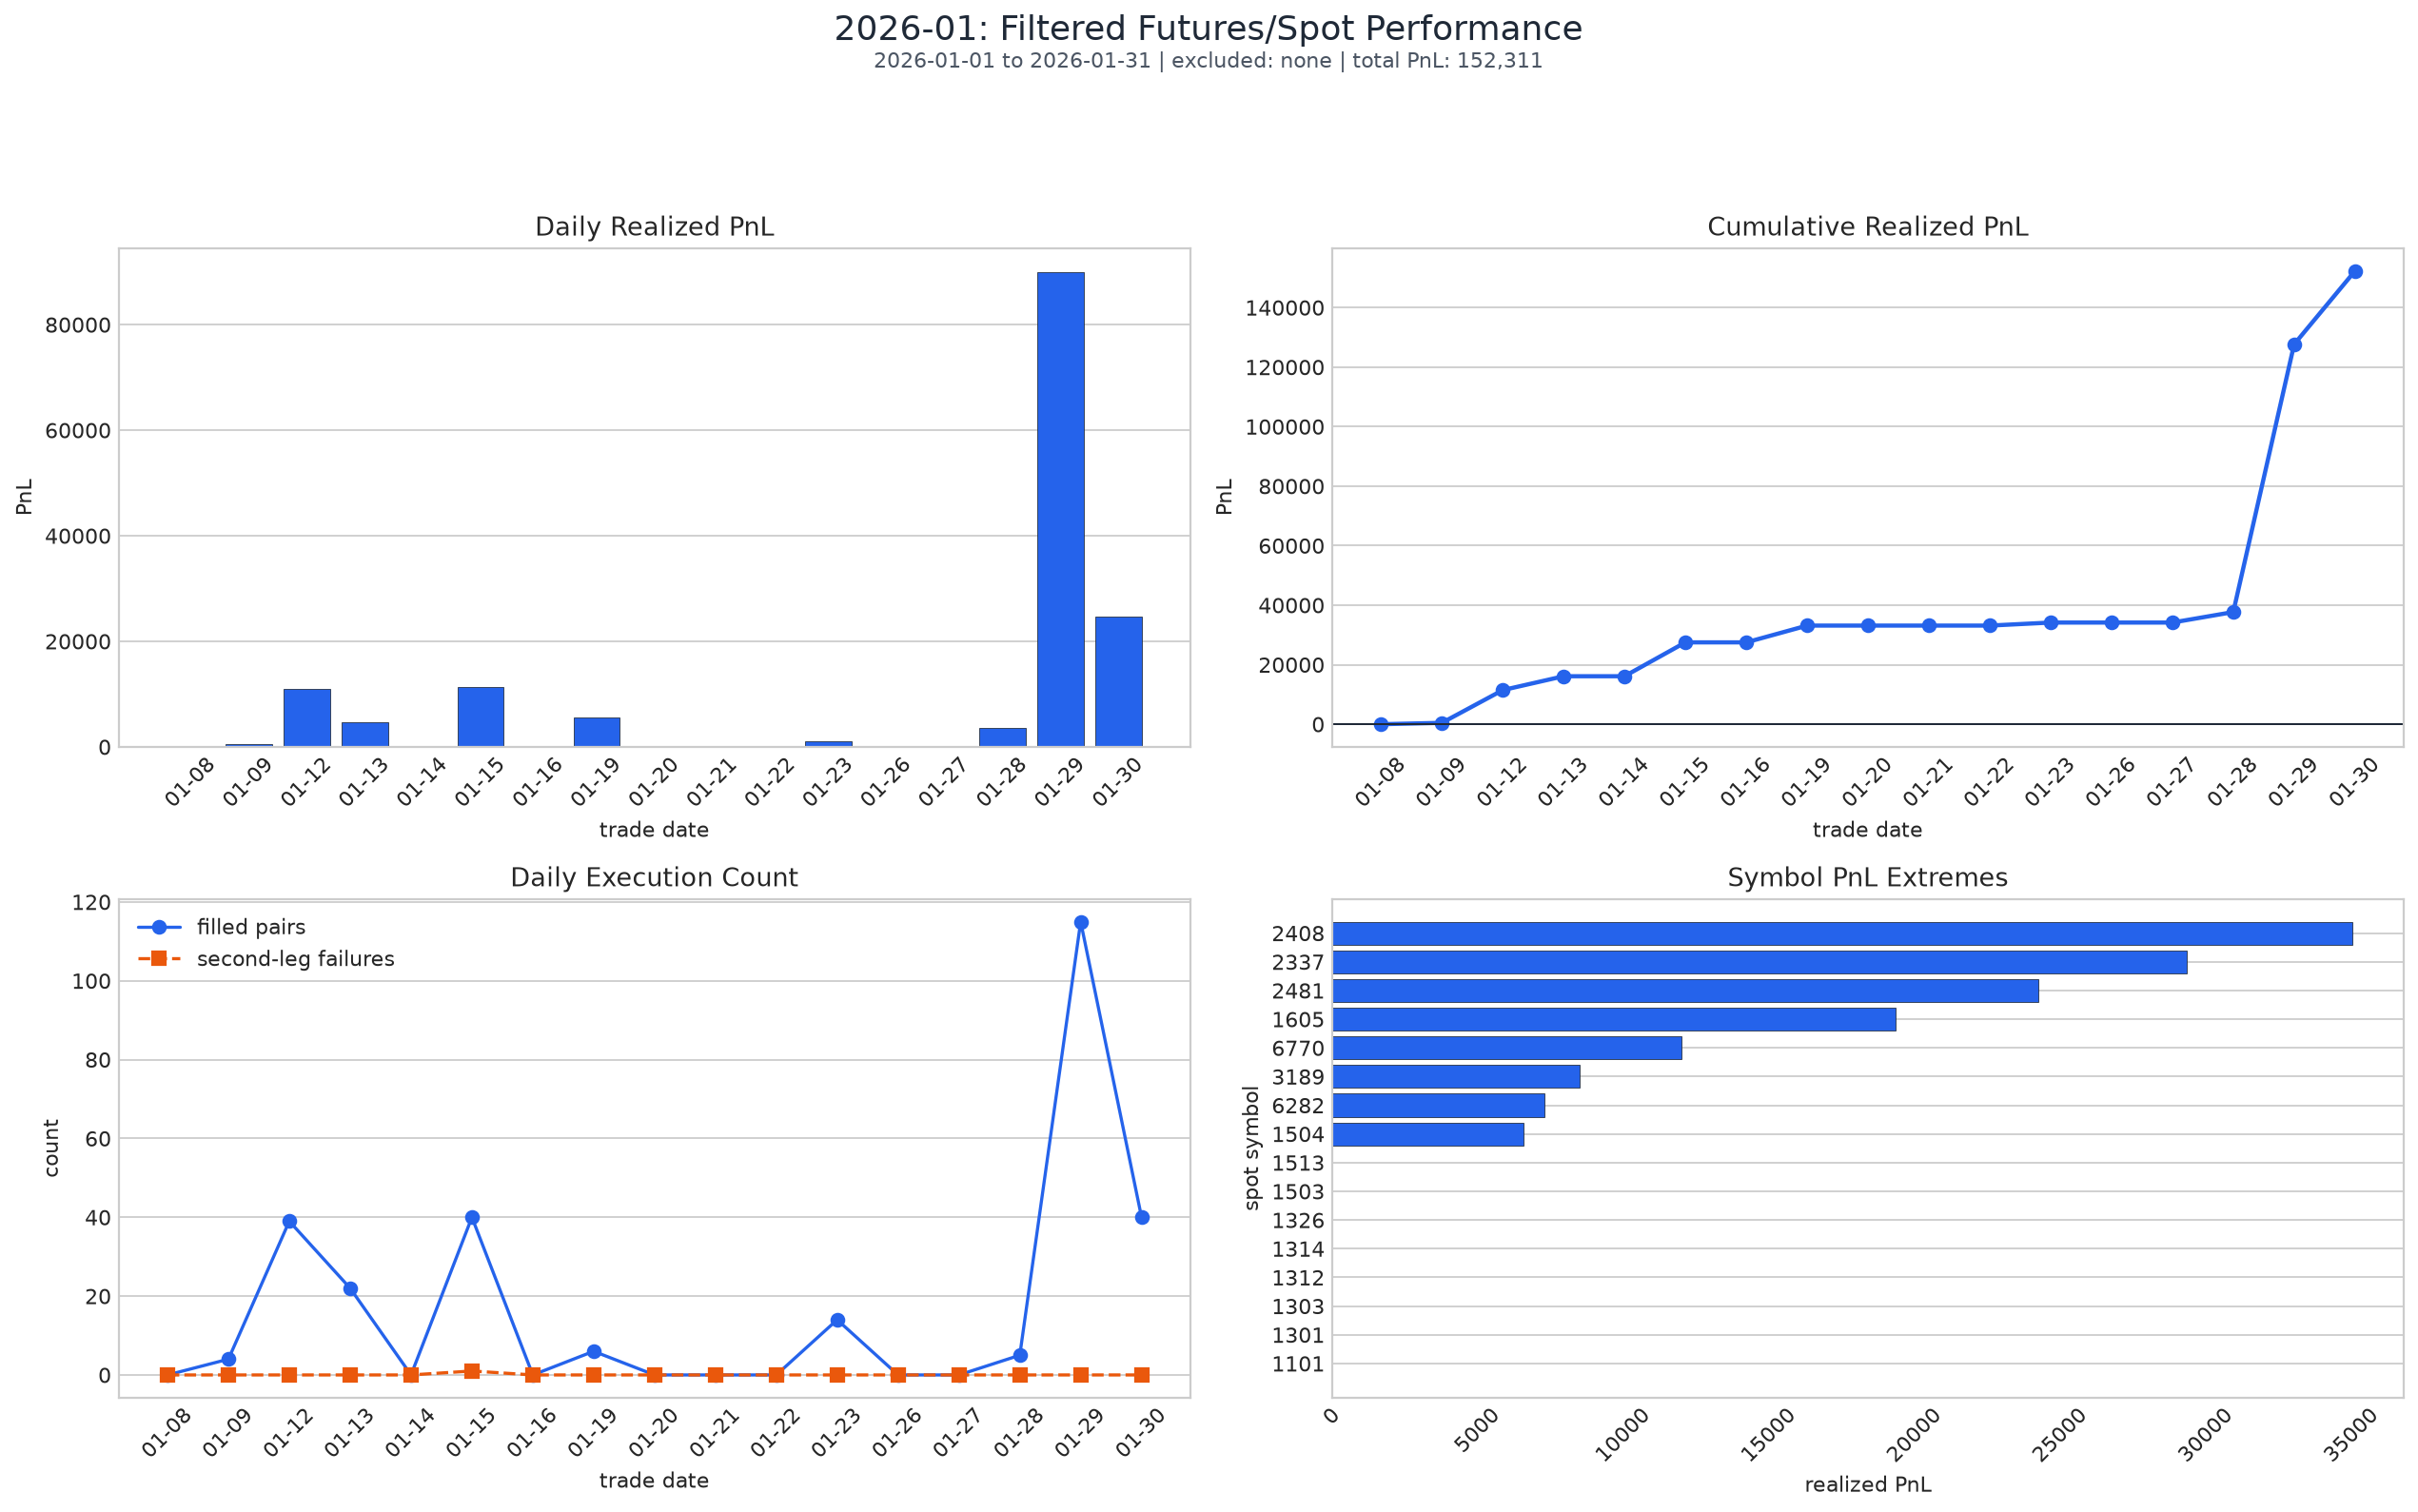

2026-02: /home/zoufuc/hftbacktest/future_spot/output/replots_filtered_202601_202607/2026-02_filtered_performance.png


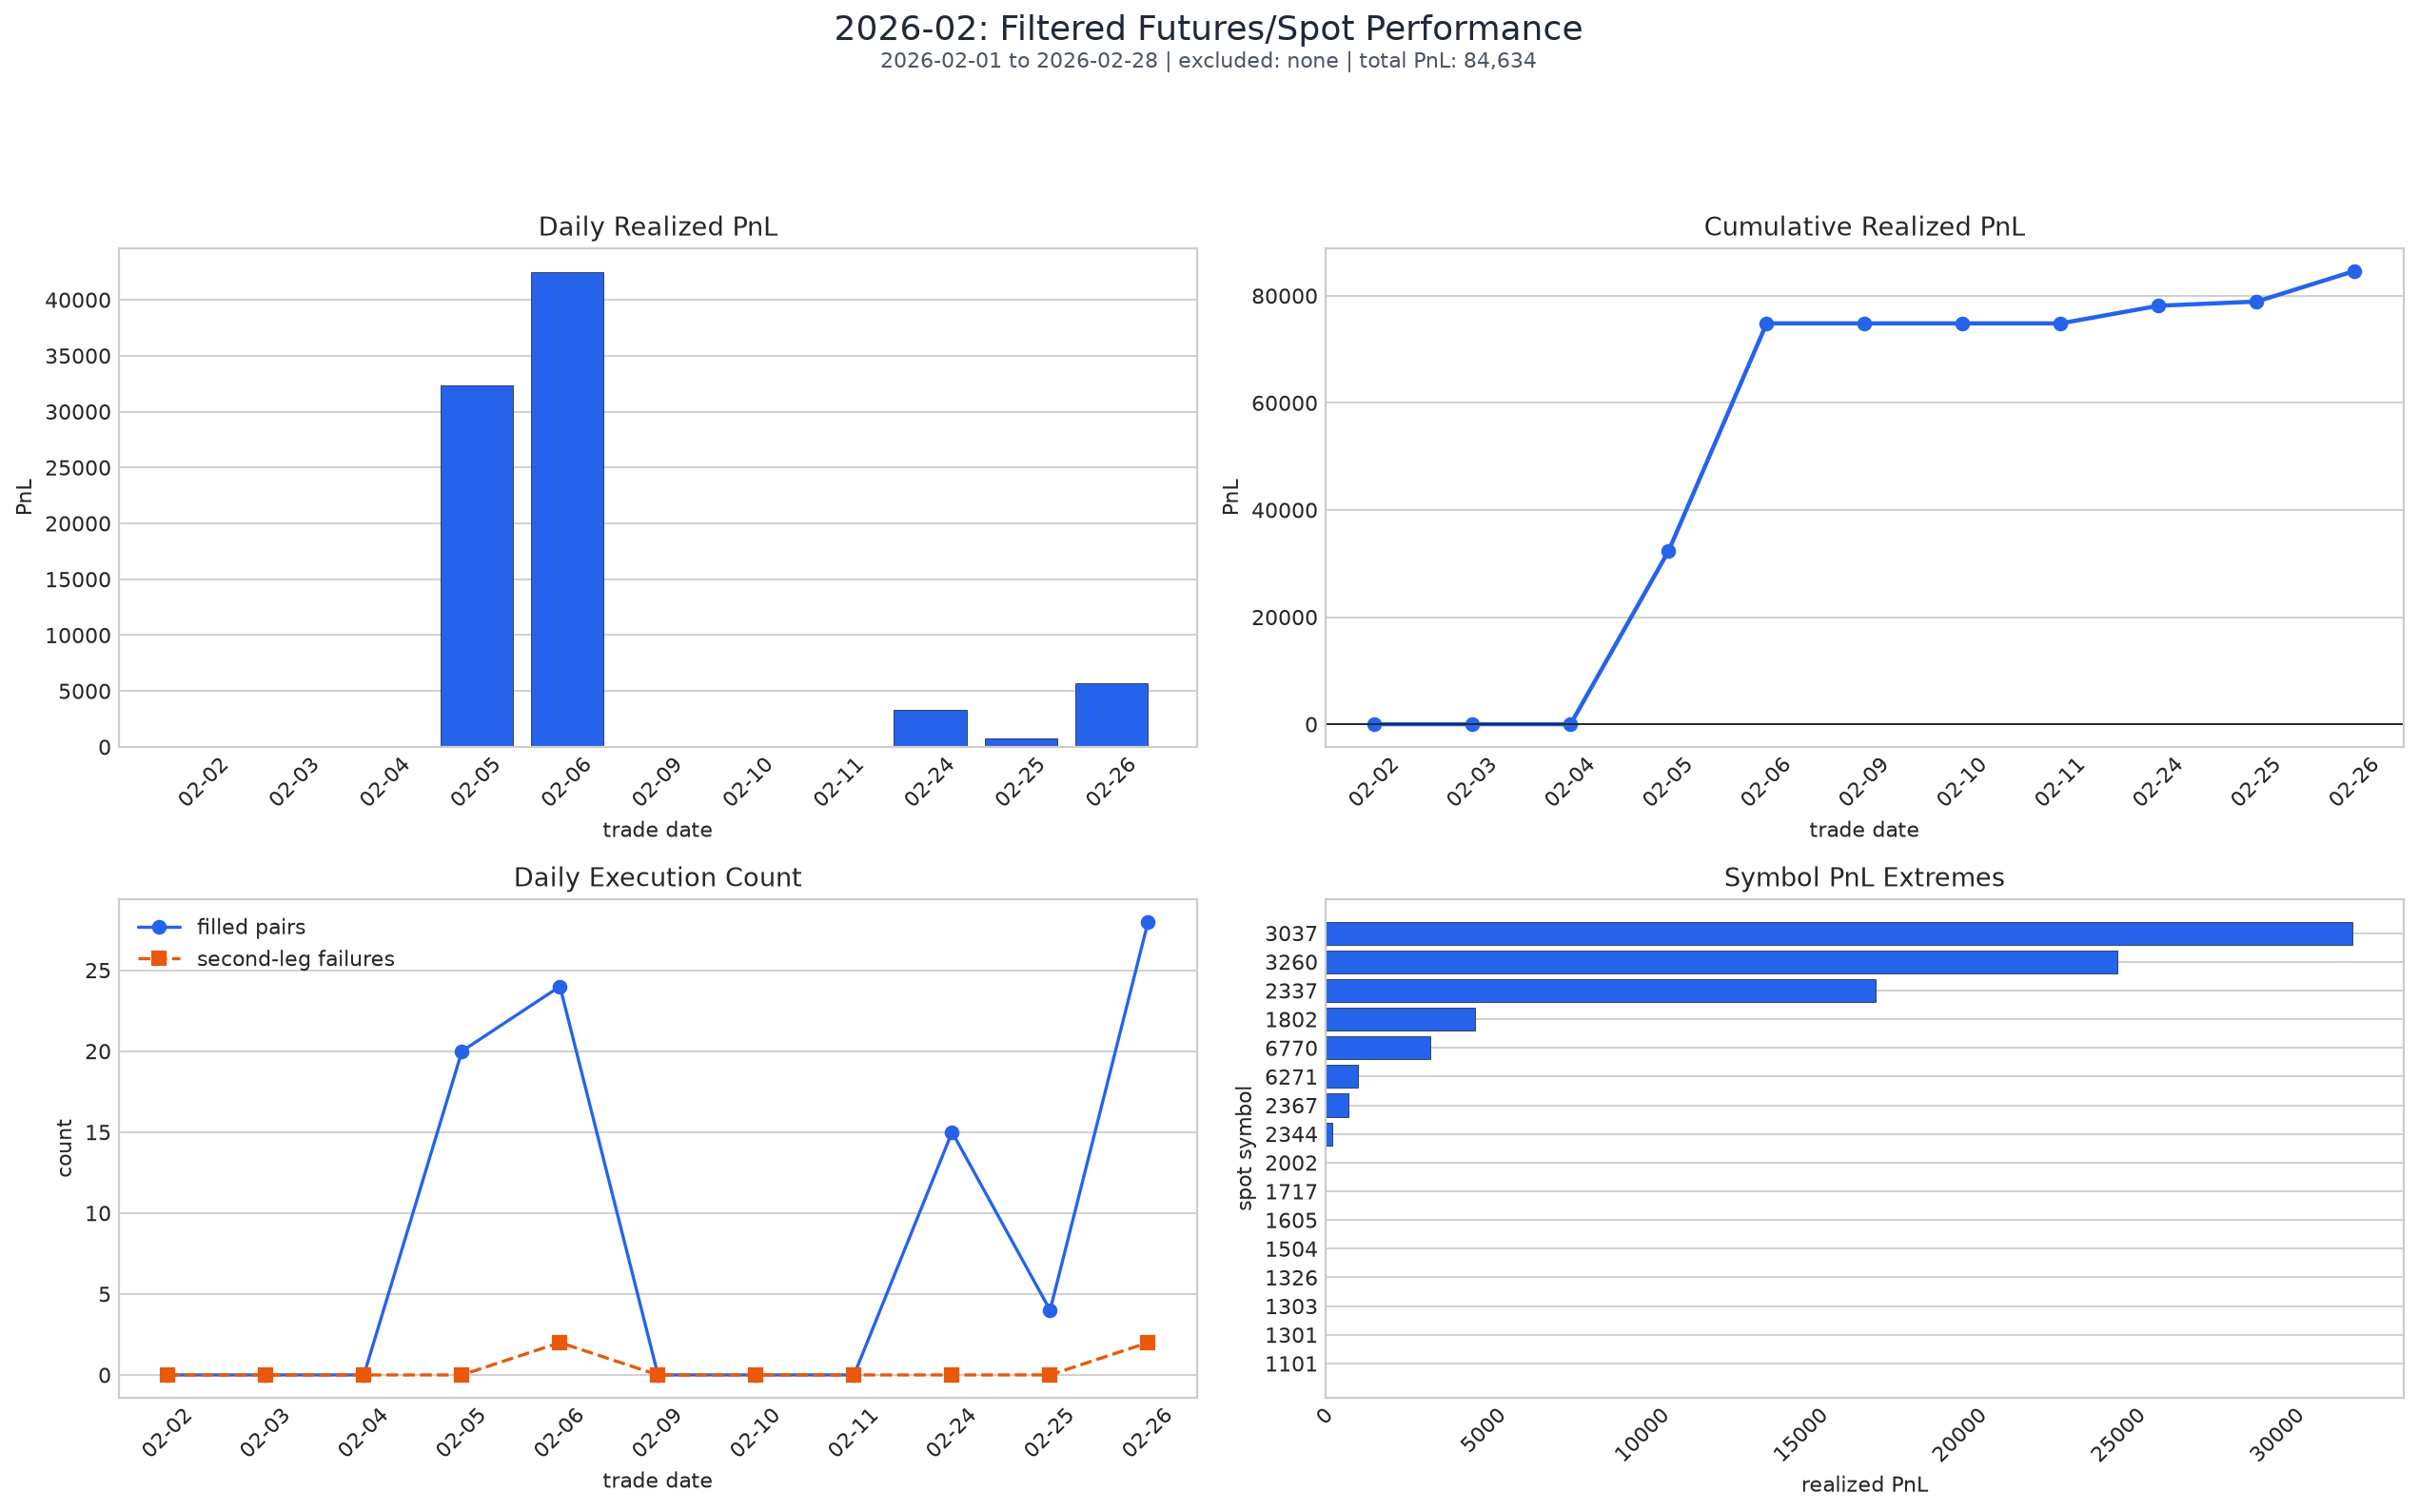

2026-03: /home/zoufuc/hftbacktest/future_spot/output/replots_filtered_202601_202607/2026-03_filtered_performance.png


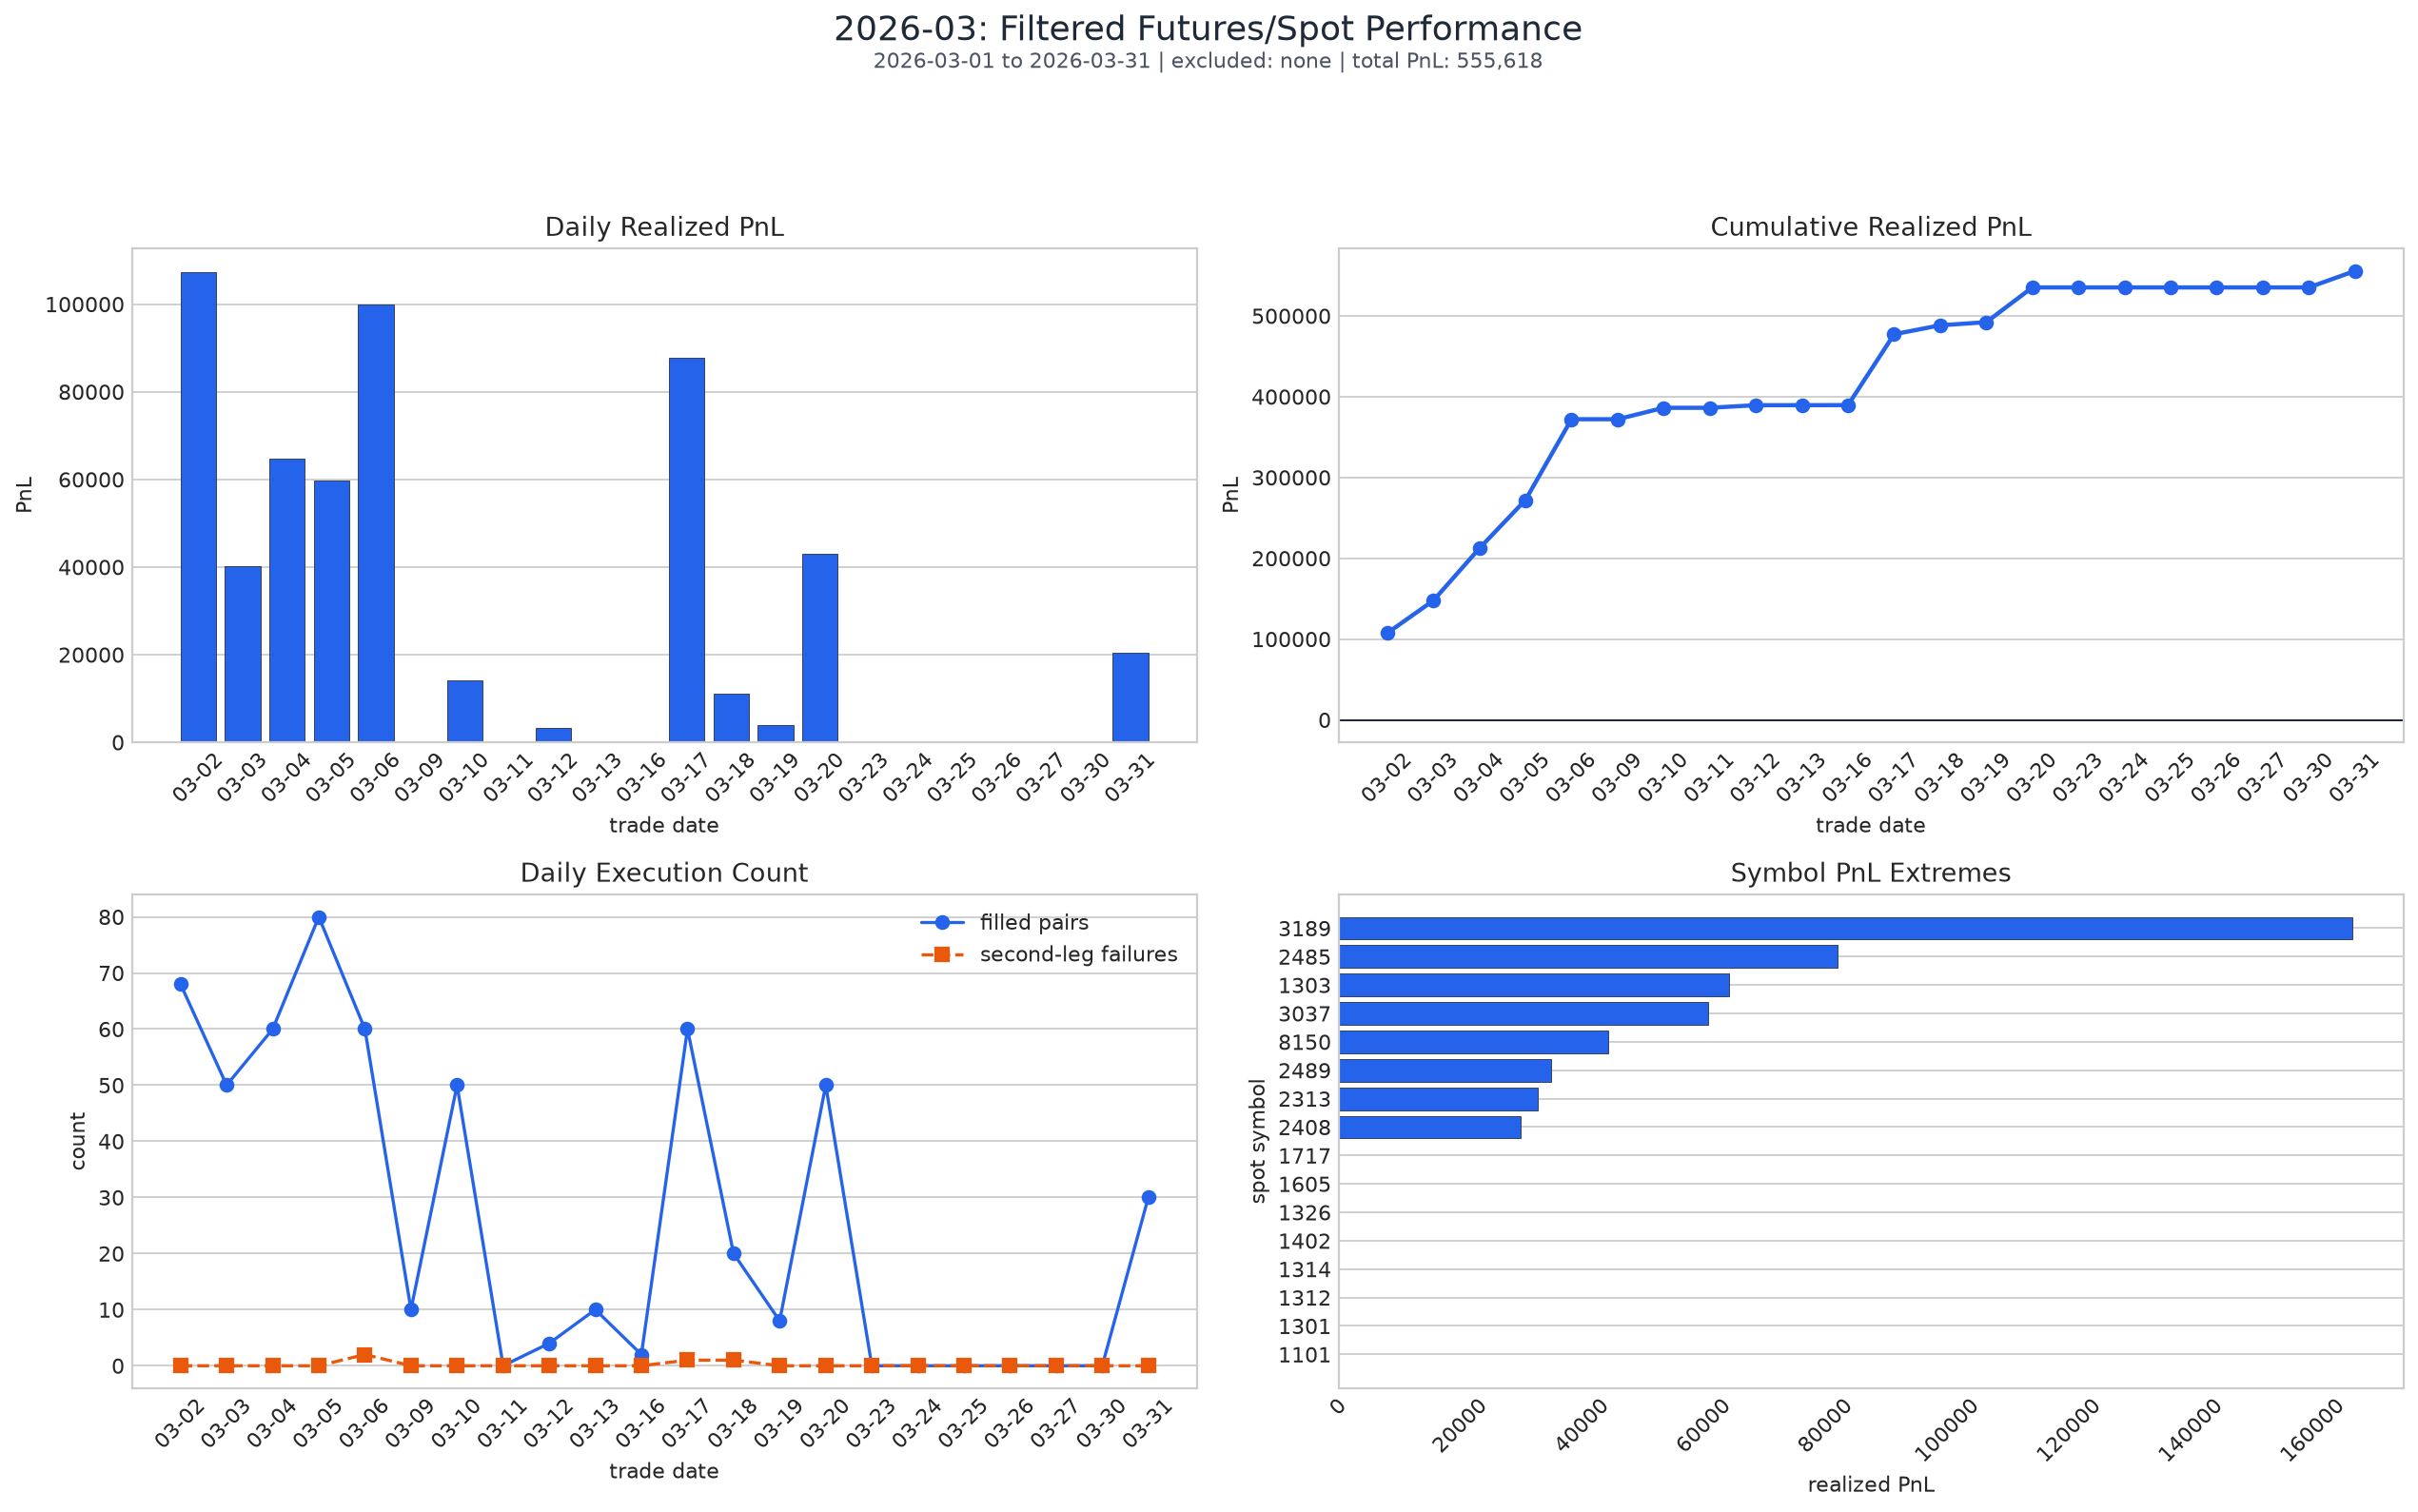

2026-04: /home/zoufuc/hftbacktest/future_spot/output/replots_filtered_202601_202607/2026-04_filtered_performance.png


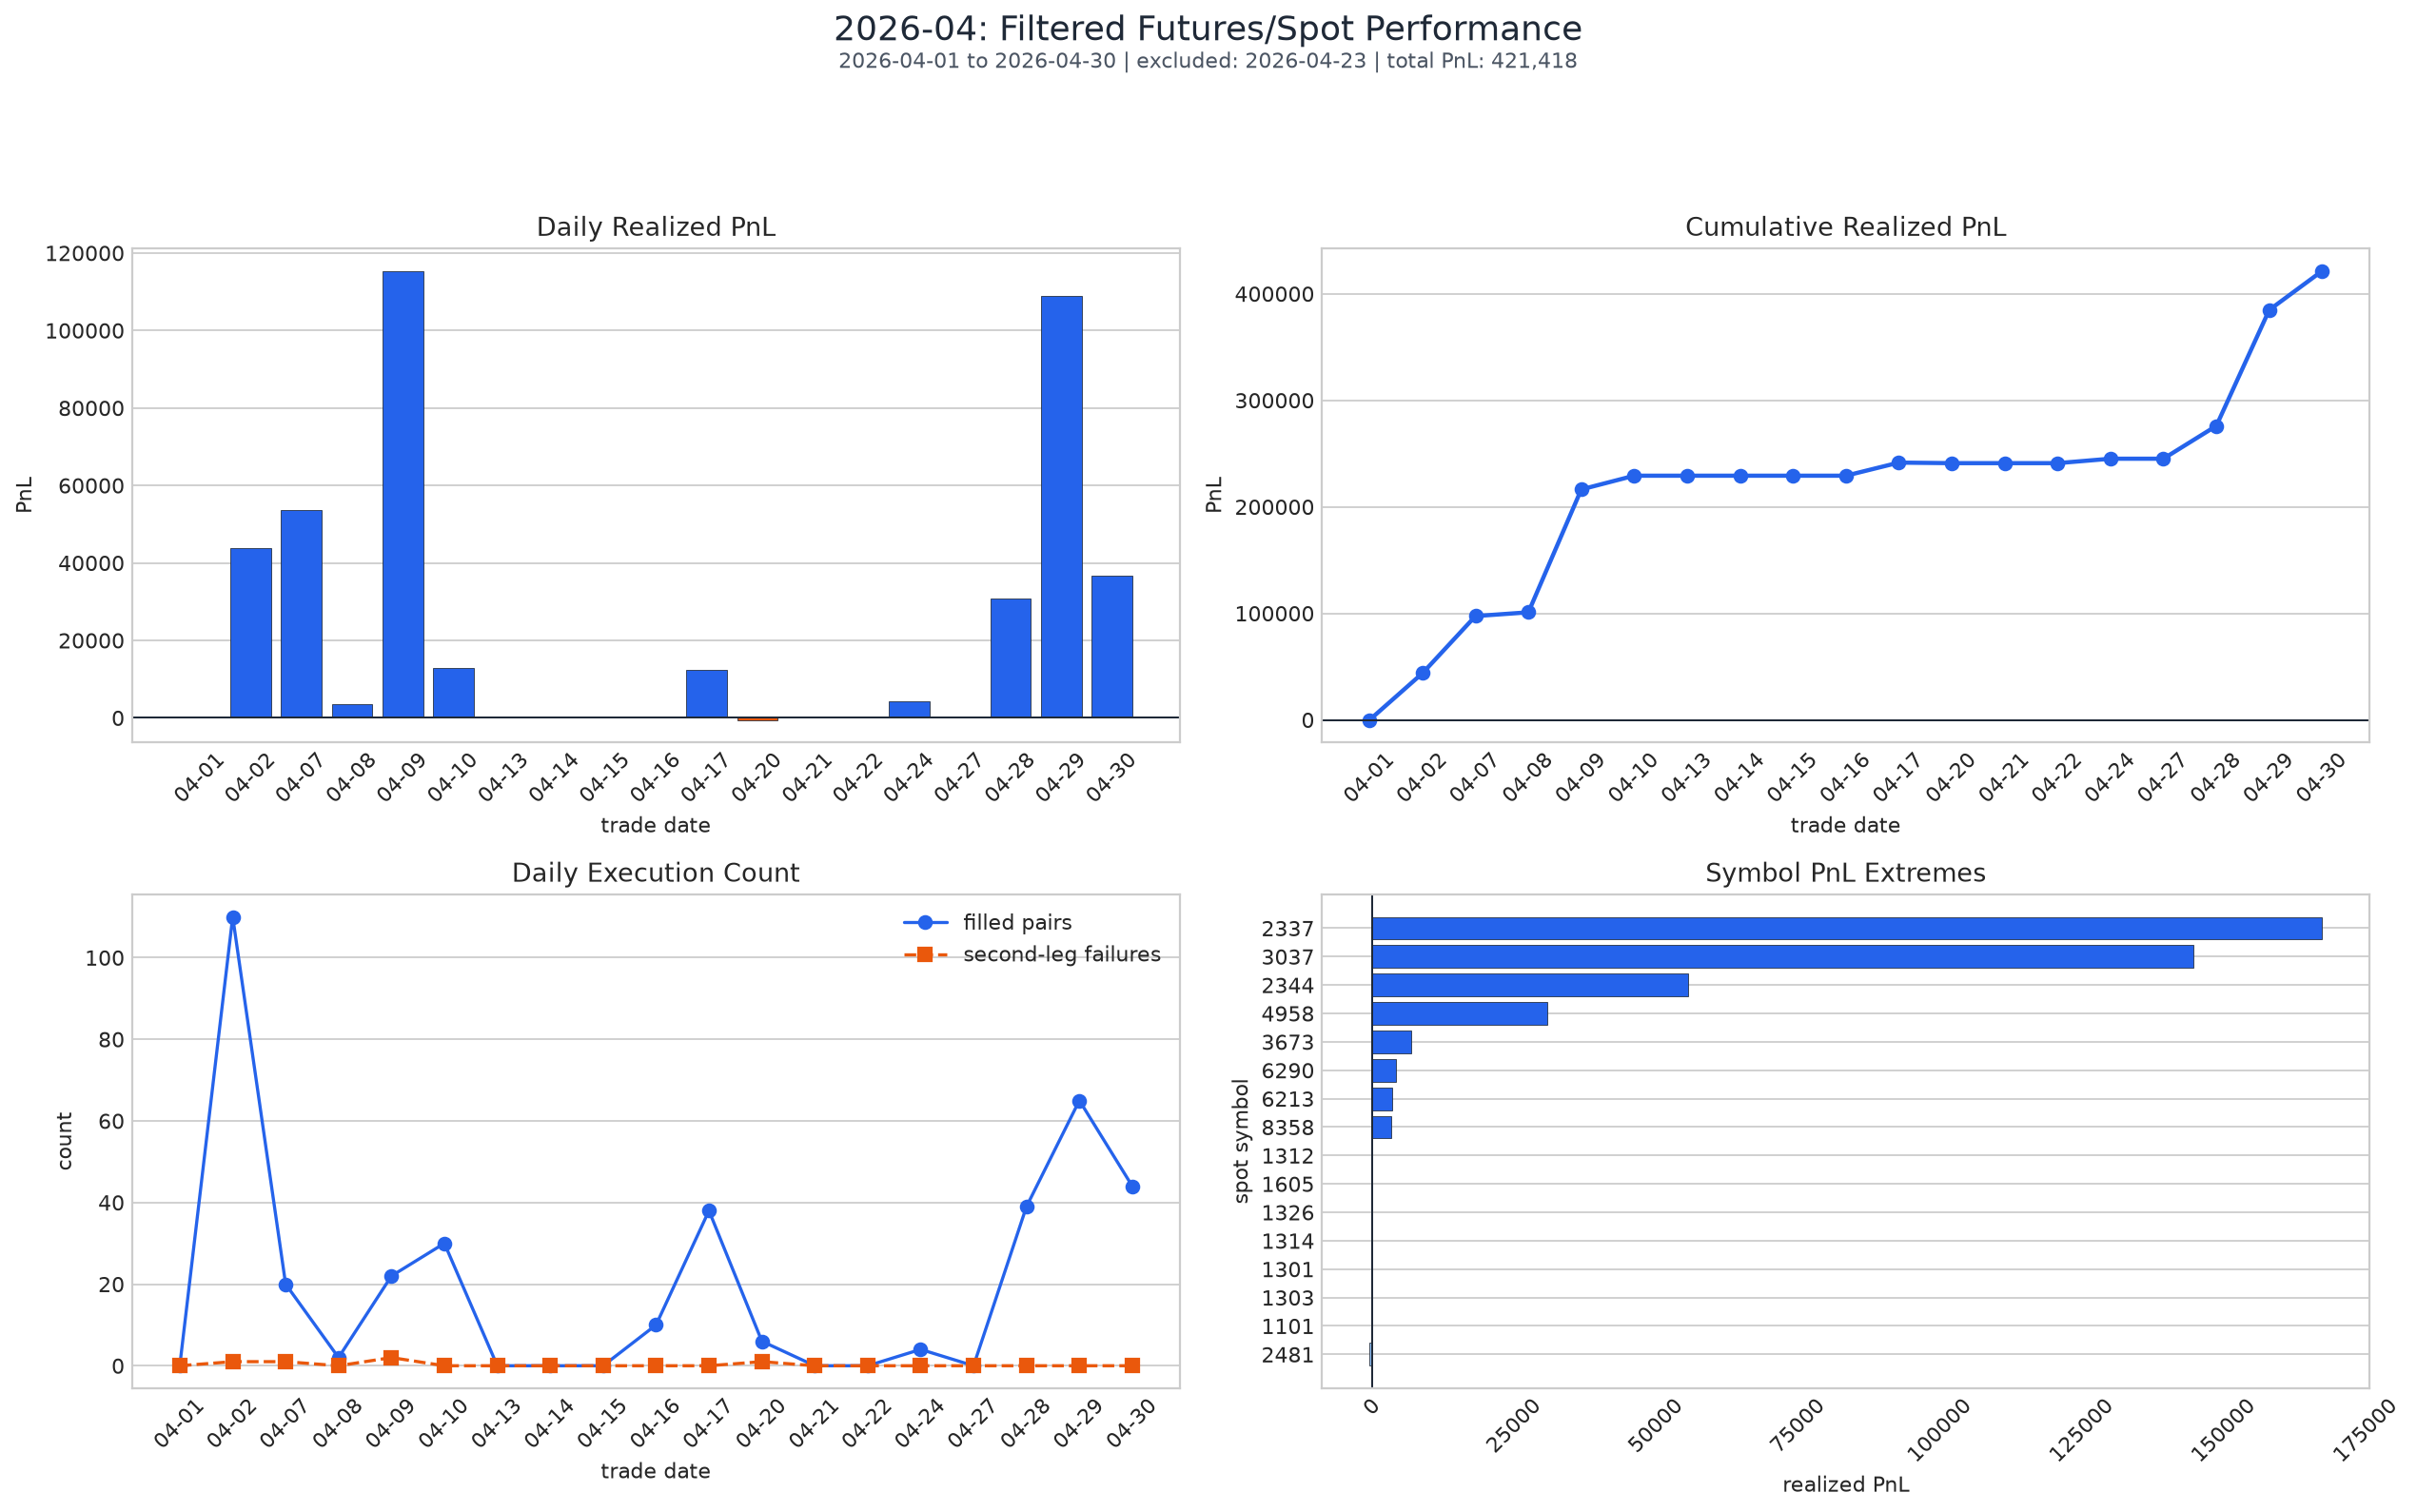

2026-05: /home/zoufuc/hftbacktest/future_spot/output/replots_filtered_202601_202607/2026-05_filtered_performance.png


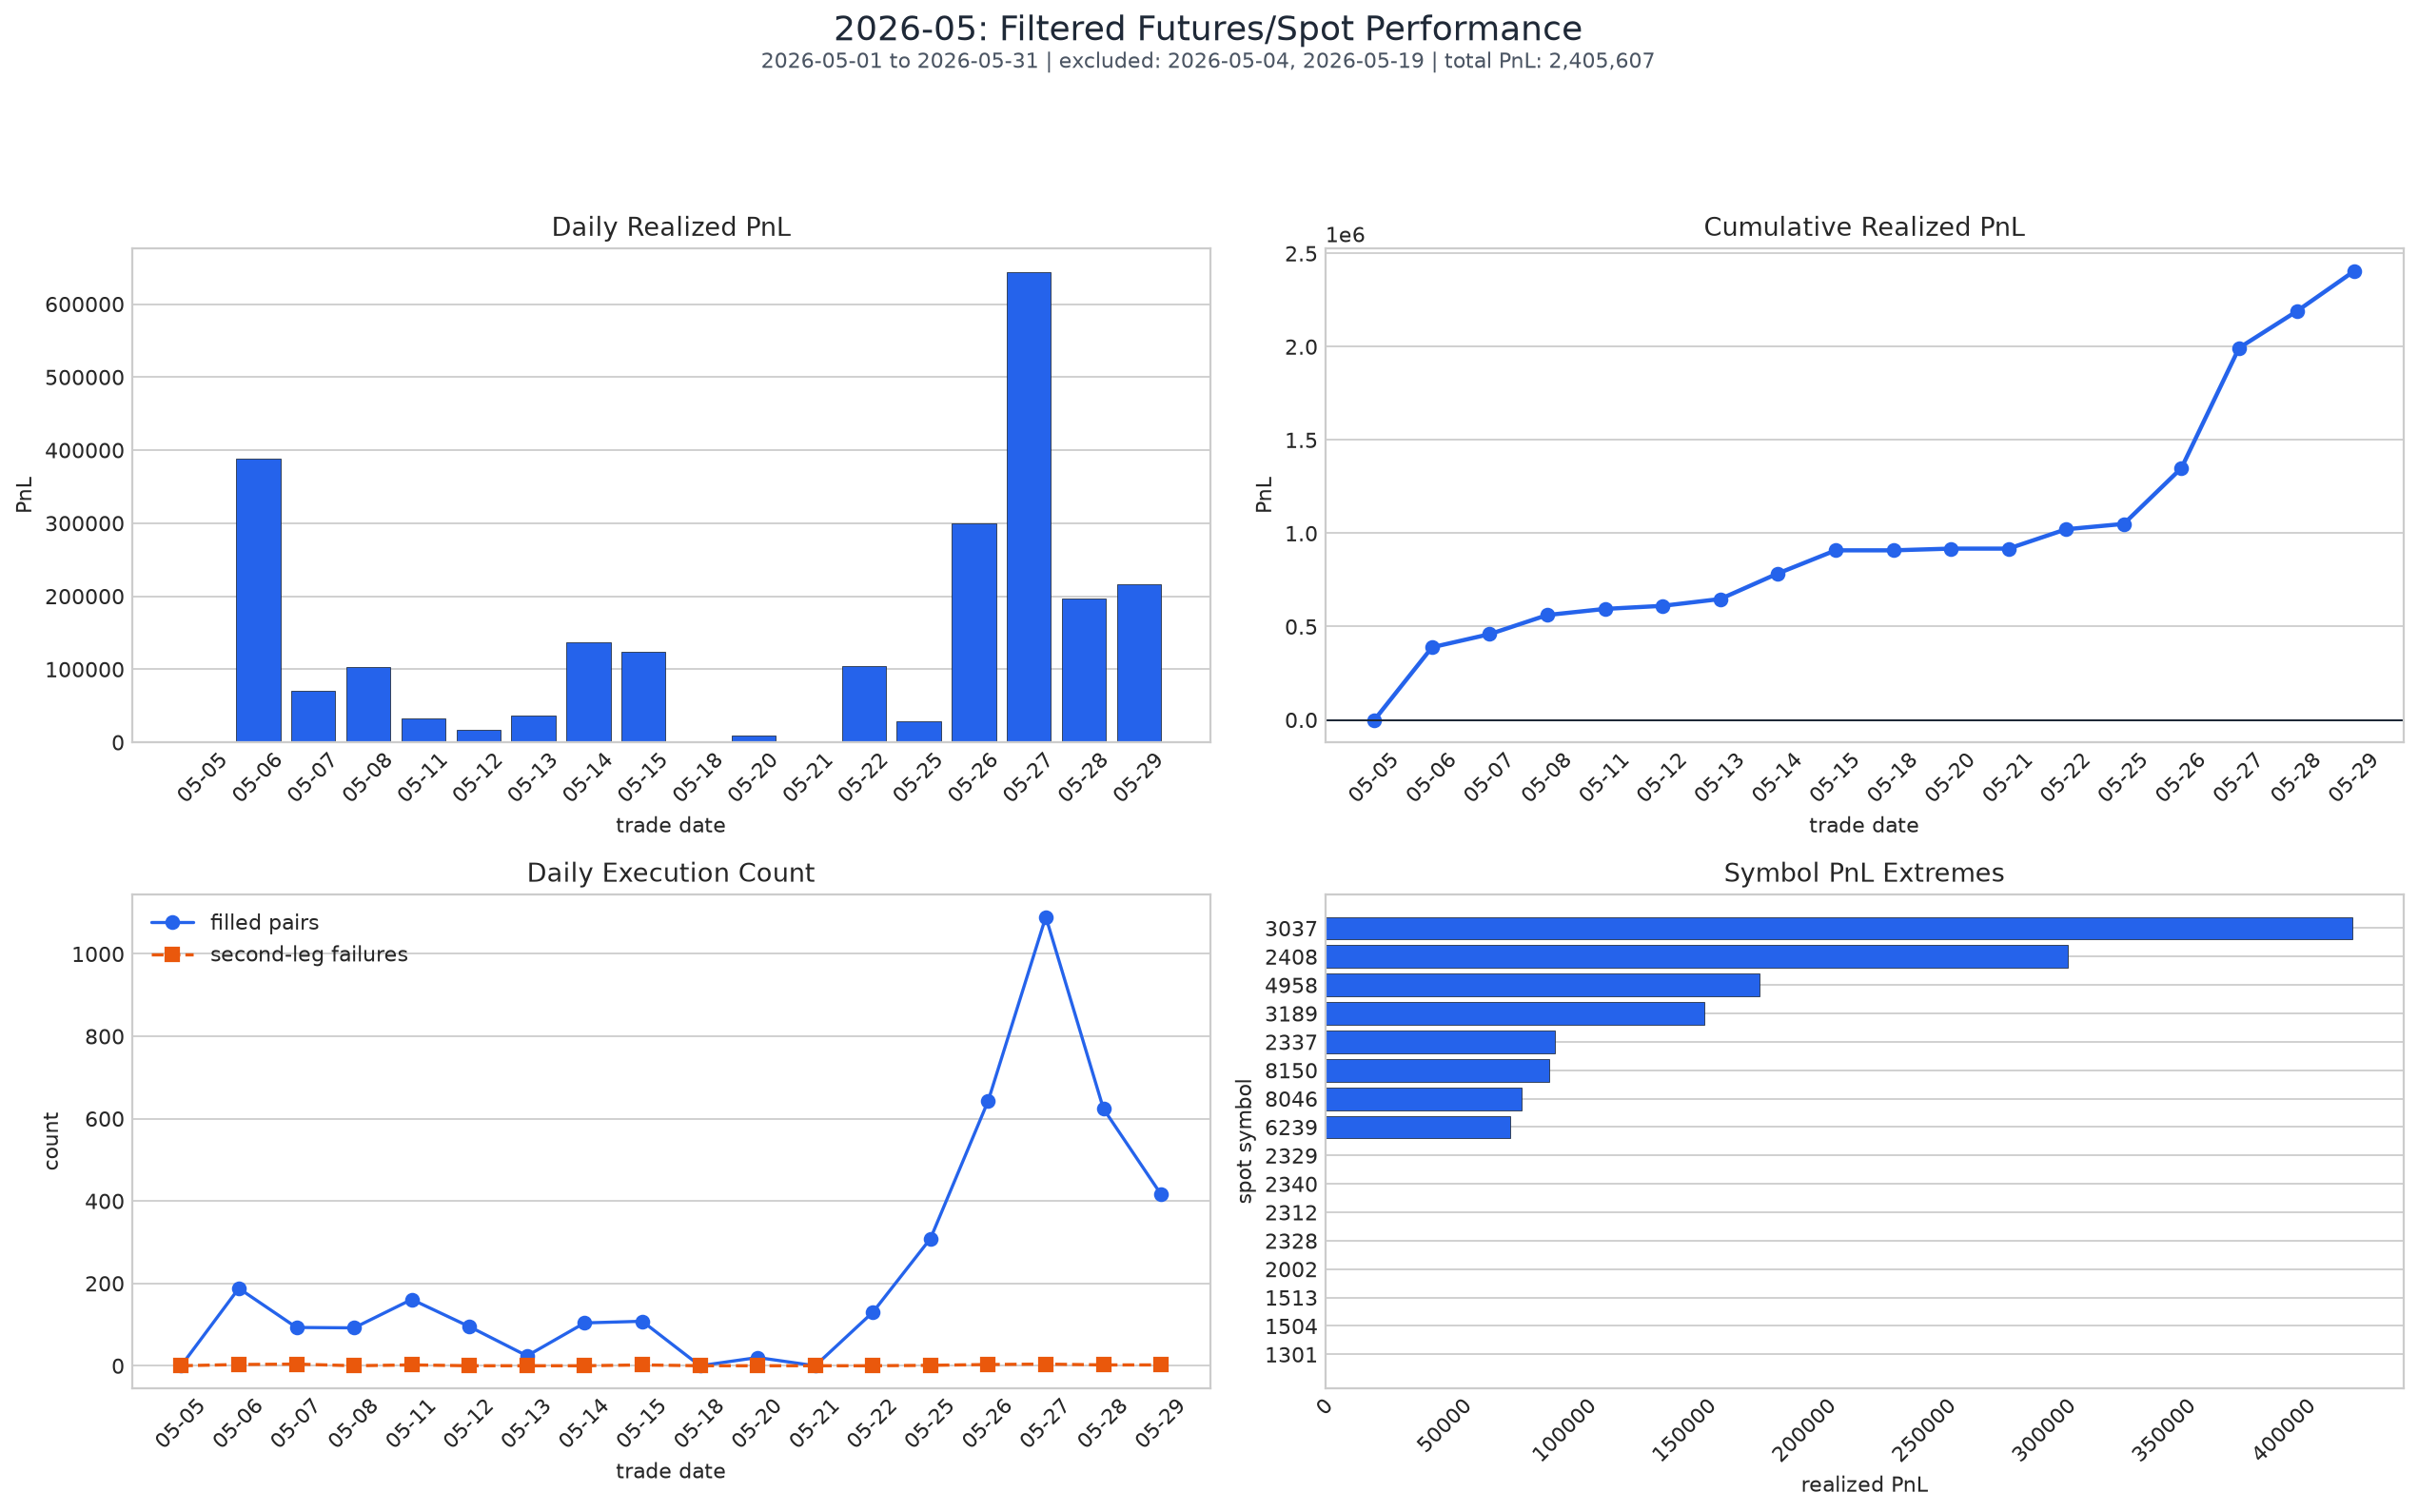

2026-06: /home/zoufuc/hftbacktest/future_spot/output/replots_filtered_202601_202607/2026-06_filtered_performance.png


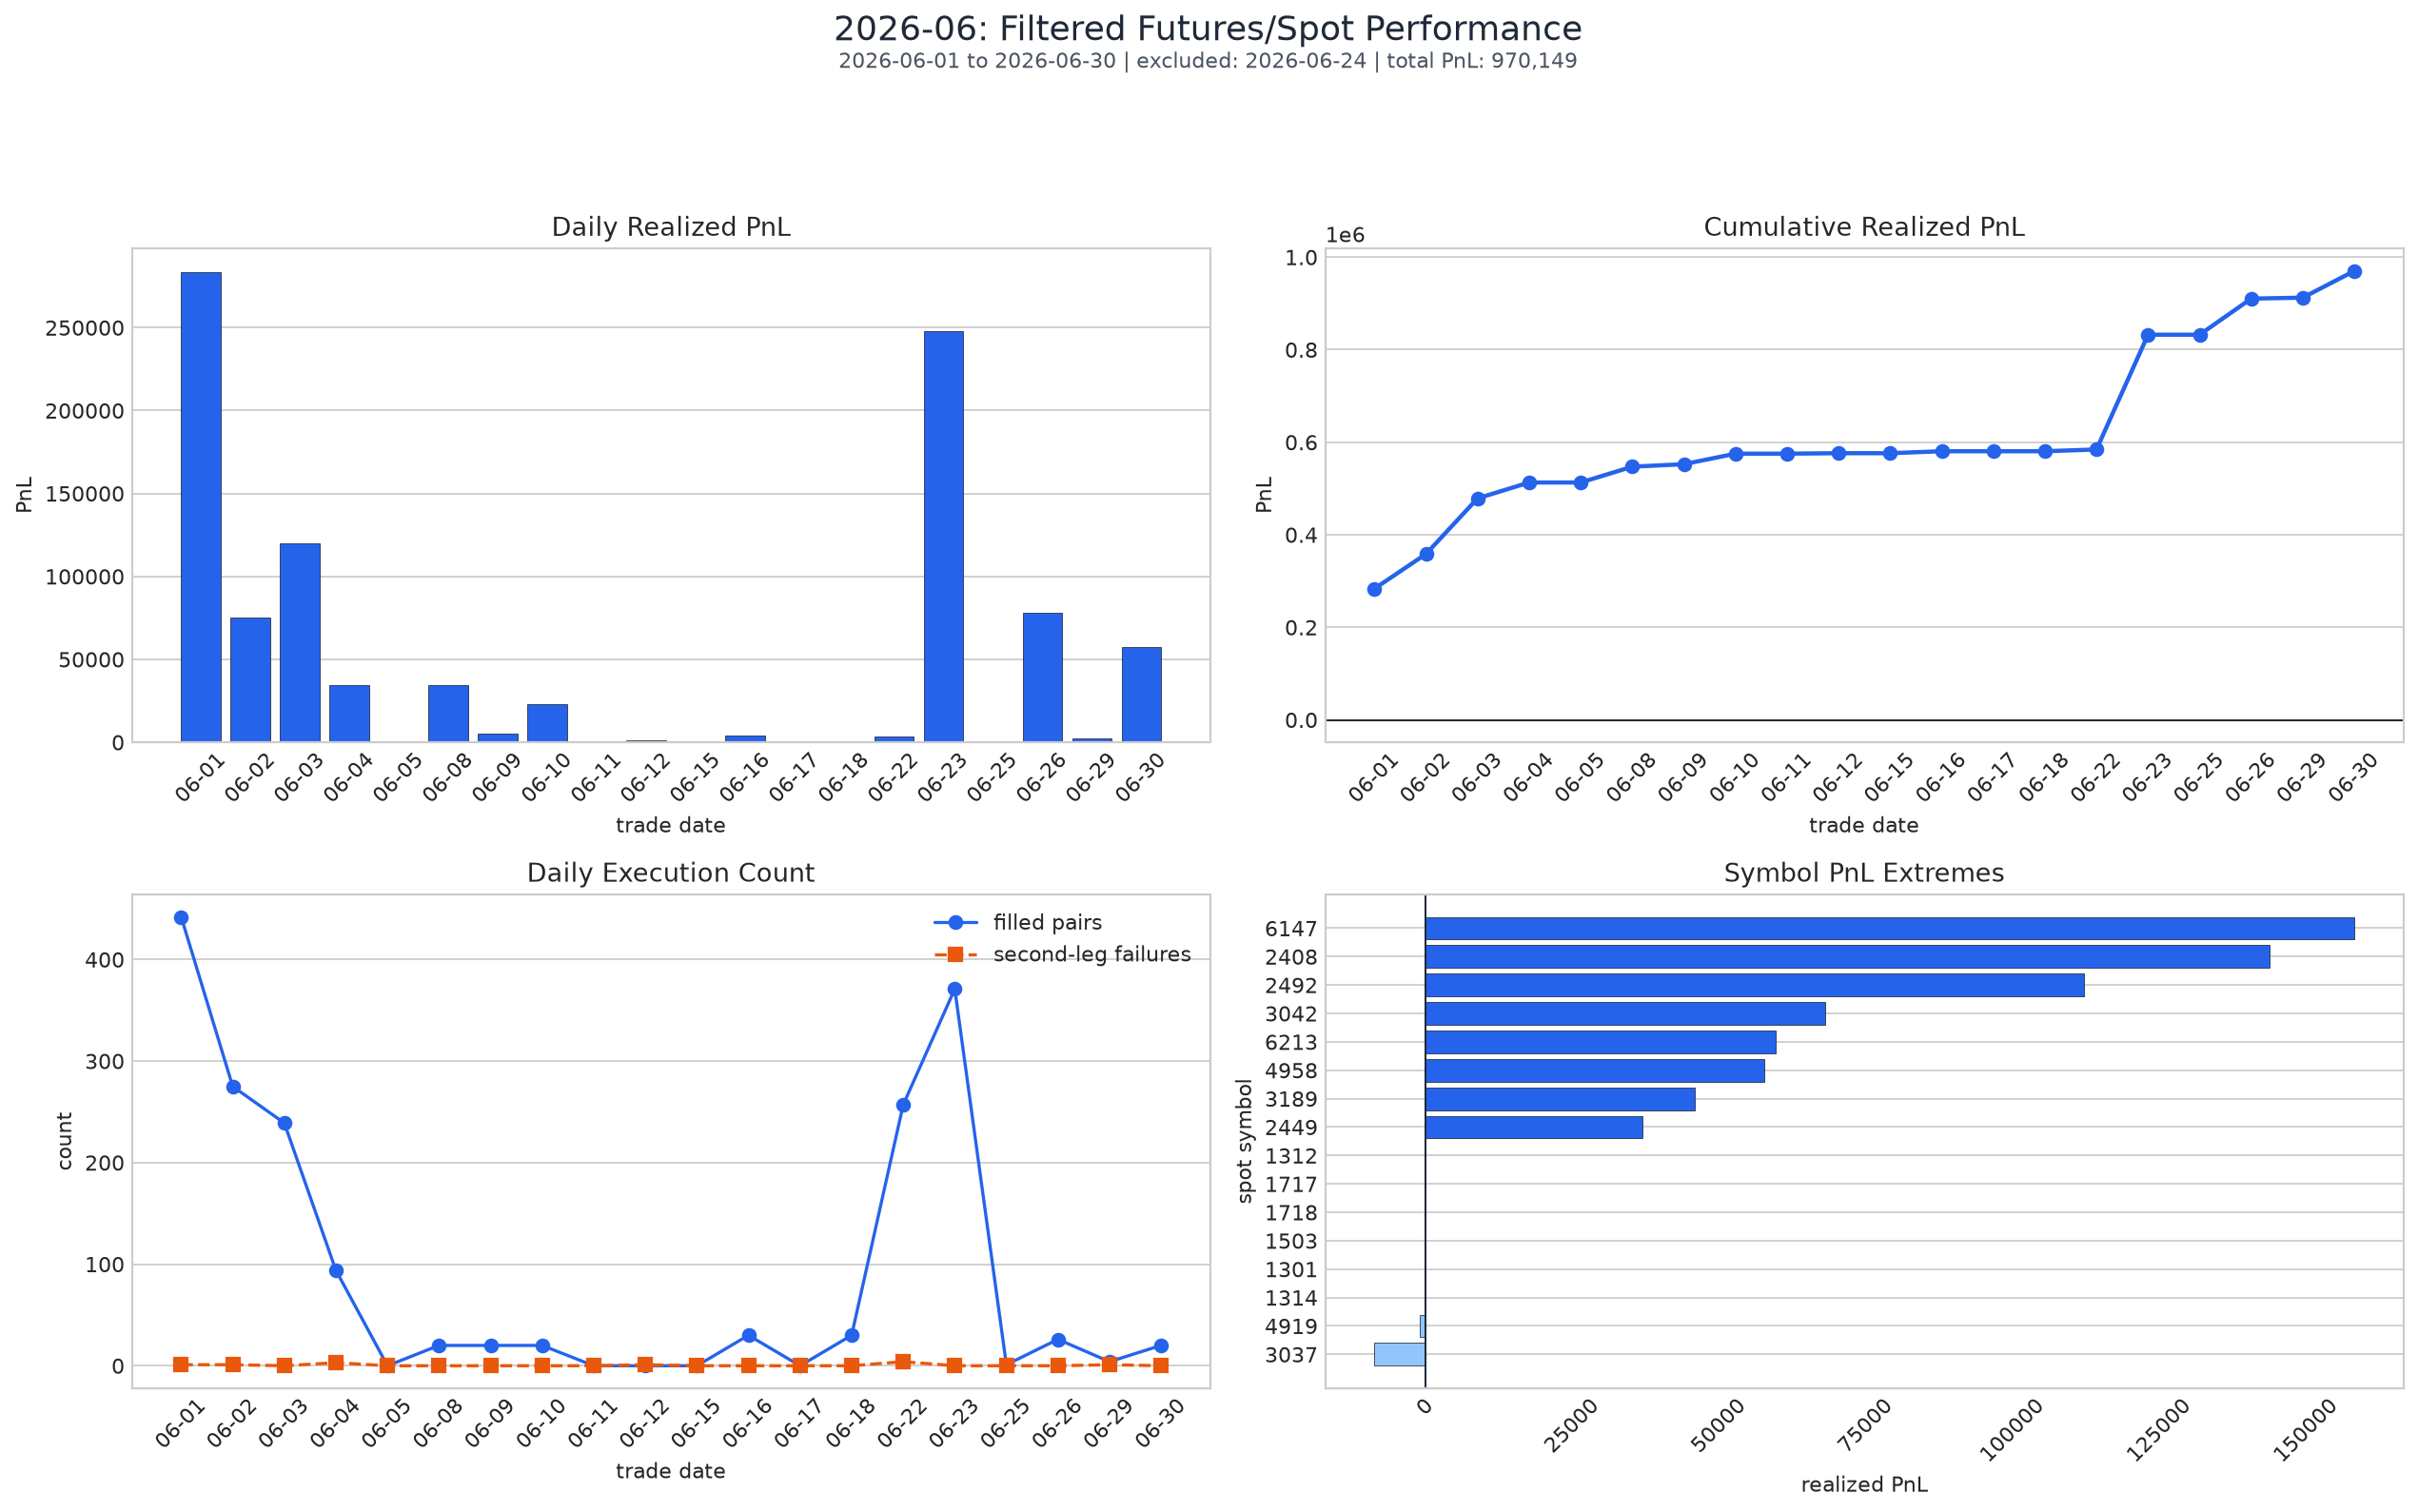

2026-07: /home/zoufuc/hftbacktest/future_spot/output/replots_filtered_202601_202607/2026-07_filtered_performance.png


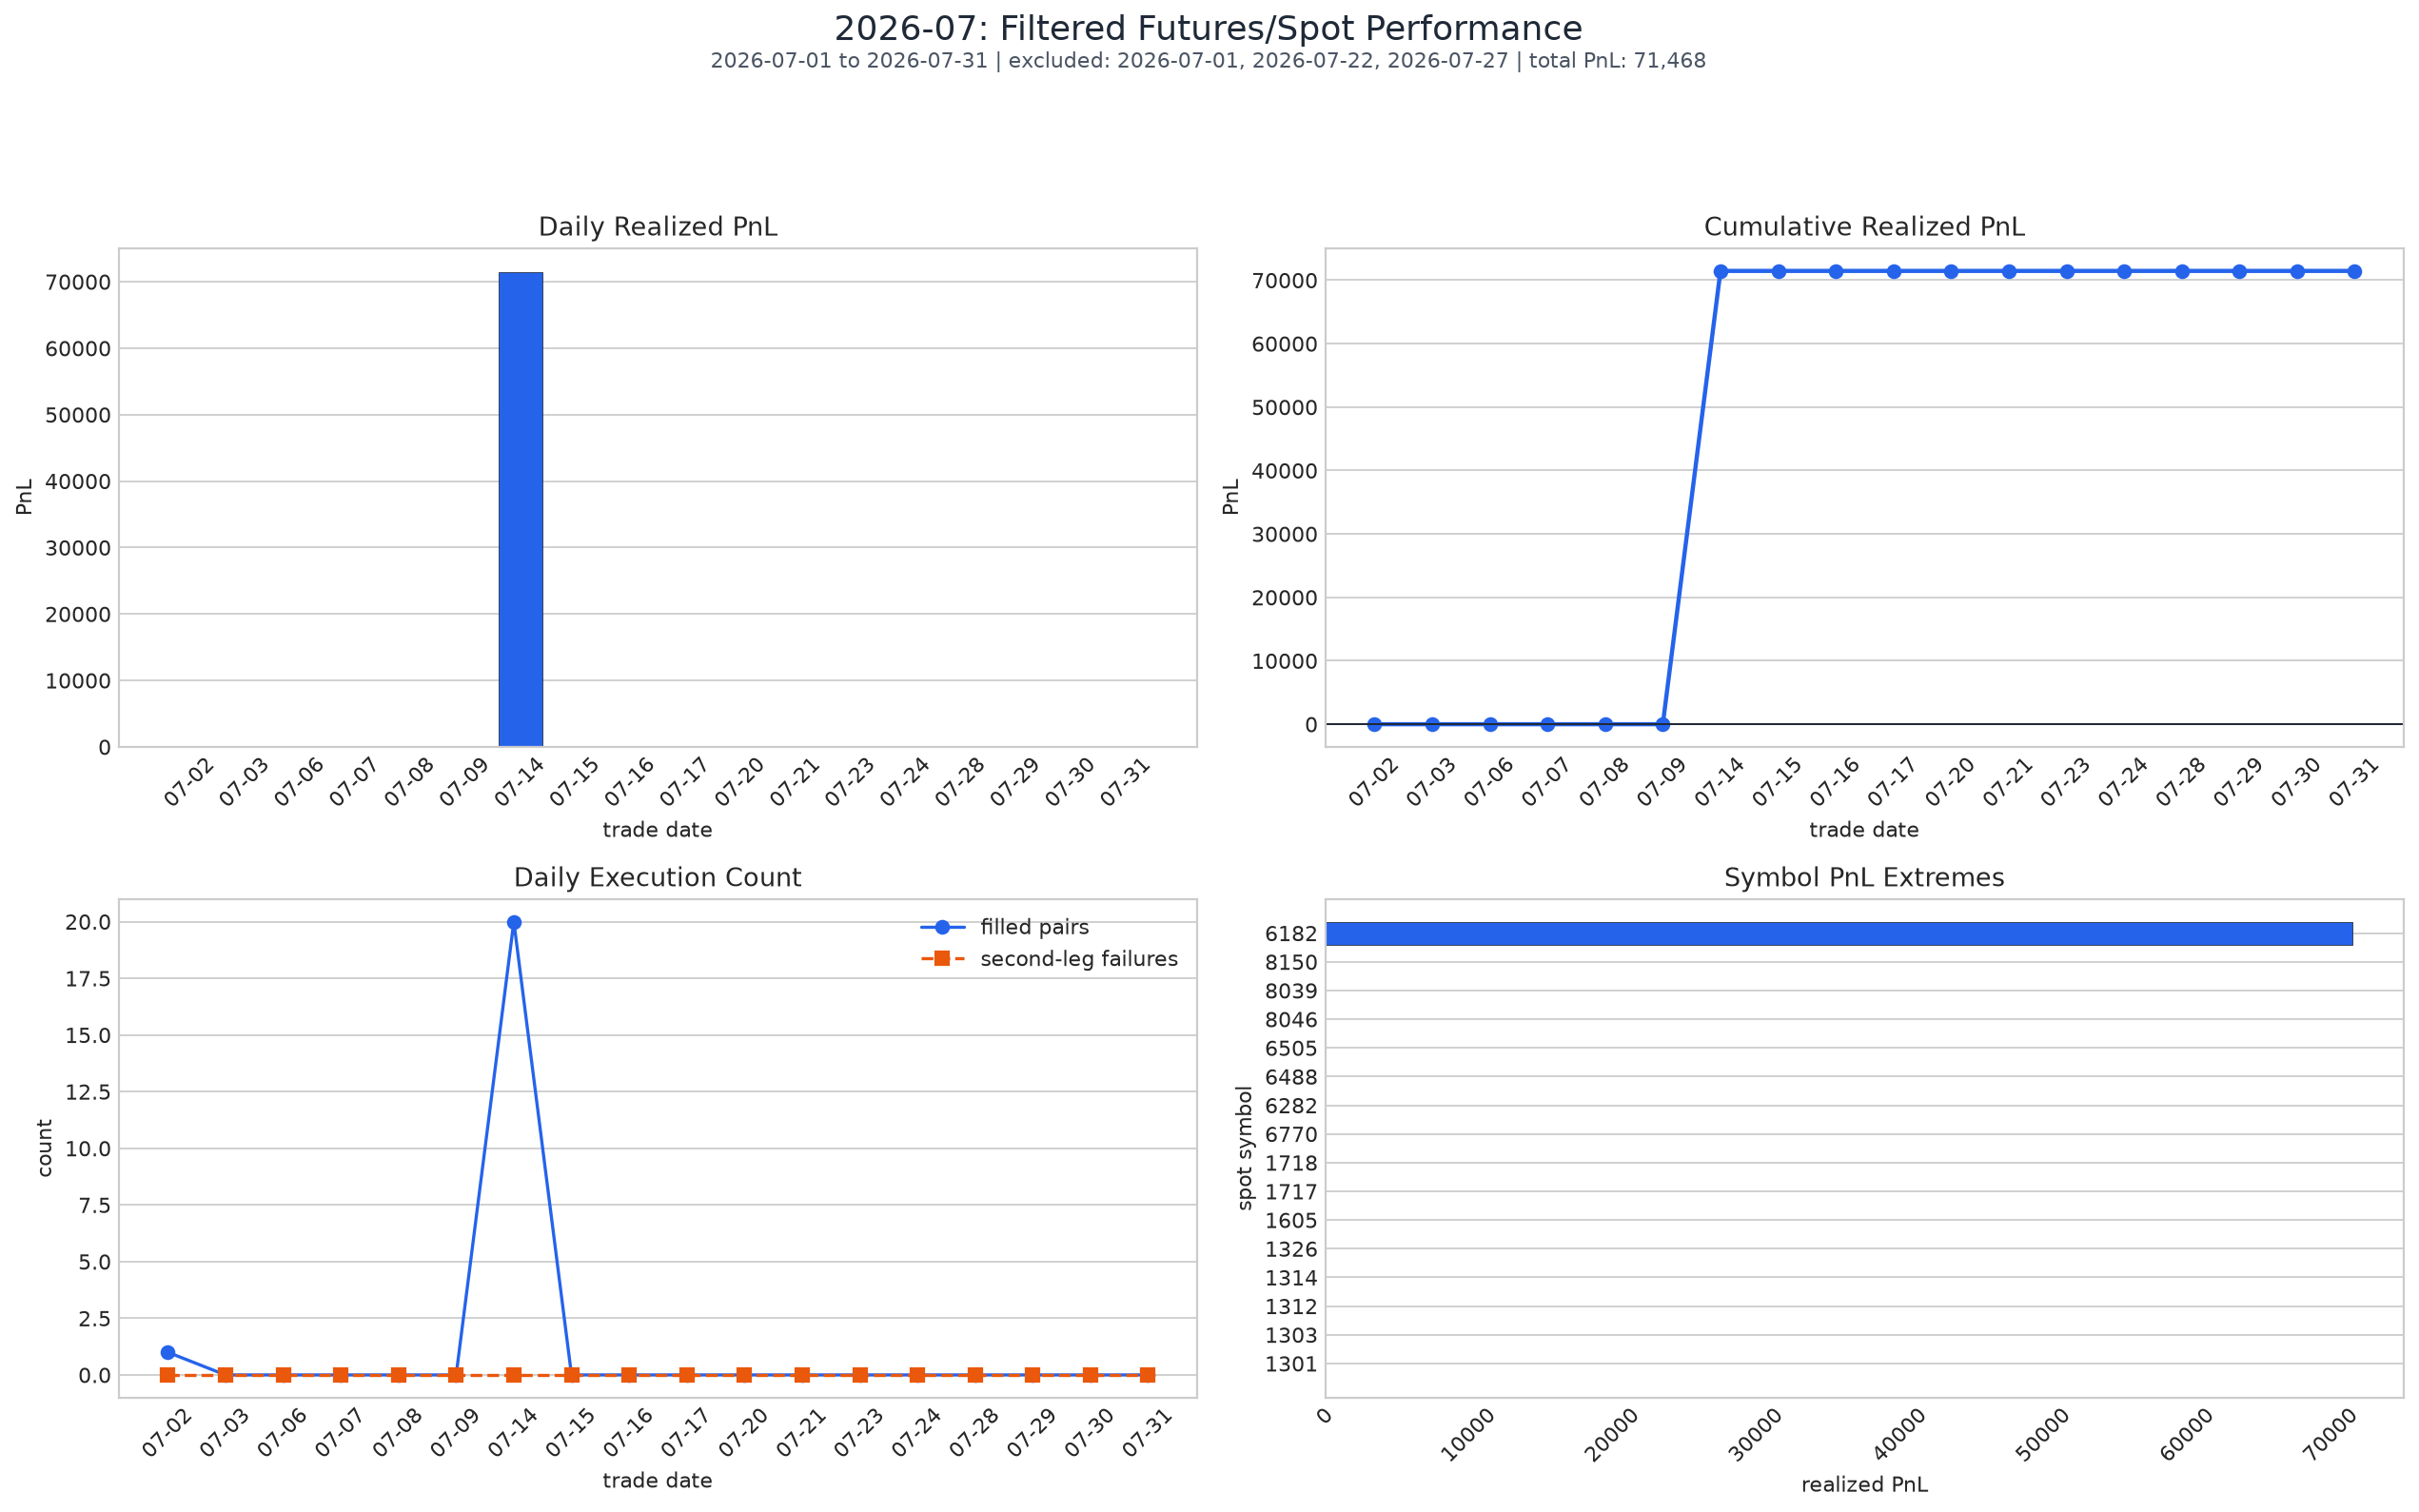

In [10]:
plot_audit = save_interval_figures(summary, PLOT_INTERVALS, FIGURE_OUTPUT_DIR)
display(plot_audit)
for row in plot_audit.itertuples(index=False):
    print(f'{row.interval}: {row.figure_path}')
    display(Image(filename=row.figure_path))

## Checks

- `filtered_plot_audit.csv` 記錄每個 interval 的起訖日、實際排除日、納入交易日、損益與圖片路徑。
- 圖表與合計都只使用未排除日期。
- 若資料來源有衝突的重複 `run_key`，載入時會直接報錯，避免悄悄選錯版本。

## Next Steps

日後只需修改 `OUTPUT_DIRS` 與 `PLOT_INTERVALS` 後重新執行，不需重跑回測。